# Mini-Proyecto - PLN | Generación de poesía en español con modelos GPT
**Experimento 1:** spanish-gpt2 · **Experimento 2:** DeepESP/gpt2-spanish · **Experimento 3:** Salamandra-2B (LoRA) · **Experimento 4:** GPT-2 desde cero

**Curso:** Procesamiento del lenguaje natural

**Autor(es):**

* Camilo Camero
* Andres Cuellar
* Andres Gonzalez
* Julian Salamanca

Los modelos de lenguaje tipo GPT aprenden el estilo del texto con el que se entrenan, y el **fine-tuning** permite desplazar ese estilo hacia un dominio distinto con relativamente pocos datos. Este proyecto explora ese cambio con tres preguntas: ¿qué tanto se transforma la generación cuando el corpus de ajuste tiene un estilo muy marcado y fácil de medir?, ¿importa qué vio el modelo durante el pre-entrenamiento?, ¿y qué papel juega su tamaño?

Para responderlas elegimos **poesía en español**. Su estilo es distintivo (versos cortos, saltos de línea, estrofas, rima) y contrasta con el registro enciclopédico de los corpus donde se entrenan estos modelos (Wikipedia, libros, web). Usamos el corpus **Poesi.as** (~25 mil poemas, mayoritariamente en español, de varios siglos). Después de un EDA del corpus, comparamos cuatro estrategias con los mismos poemas, los mismos prompts y las mismas métricas:

* **Experimento 1 · spanish-gpt2** (`mrm8488`): GPT-2 small entrenado desde cero con ~20 GB de texto general en español. Fine-tuning completo.
* **Experimento 2 · DeepESP/gpt2-spanish**: GPT-2 small entrenado con Wikipedia y ~8 GB de libros (incluida poesía). Hipótesis: haber visto literatura facilita el cambio de estilo.
* **Experimento 3 · Salamandra-2B**: LLM moderno y multilingüe con ~2B de parámetros (un GPT-2 small tiene ~124M). Es demasiado grande para fine-tuning completo en una GPU L4 (24 GB), así que usamos **LoRA**.
* **Experimento 4 · GPT-2 desde cero**: un GPT-2 pequeño sin pre-entrenamiento, entrenado solo con los poemas. Es un *control*: aísla cuánto aporta el pre-entrenamiento.

Para cada modelo medimos qué tan bien predice poemas que no vio (**bits por carácter**, comparable entre tokenizadores distintos), qué tan parecida es su generación a un poema real (**métricas de estilo**) y cómo se ve el texto generado, antes y después del fine-tuning.

#### Referencias
- Dataset: [Poesi.as (Zenodo, DOI 10.5281/zenodo.5718261)](https://doi.org/10.5281/zenodo.5718261) · [repositorio](https://github.com/linhd-postdata/poesi.as)
- Modelos: [mrm8488/spanish-gpt2](https://huggingface.co/mrm8488/spanish-gpt2) · [DeepESP/gpt2-spanish](https://huggingface.co/DeepESP/gpt2-spanish) · [BSC-LT/salamandra-2b](https://huggingface.co/BSC-LT/salamandra-2b)
- [LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685)
- [Improving Language Understanding by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf)

## 0. Configuración
Se recomienda un runtime con GPU (L4 en Colab). Todos los parámetros que afectan la comparación están en la tercera celda para que sean fáciles de ajustar.

In [ ]:
import warnings

warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
    # torchvision suele dar problemas en Colab y no lo necesitamos para este notebook.
    !pip uninstall -y torchvision torchao
    # peft: LoRA (Experimento 3) | sentencepiece/protobuf: tokenizador de Salamandra
    !pip install -q peft sentencepiece protobuf
except ImportError:
    IN_COLAB = False

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [ ]:
import os, re, gc, json, math, time, unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
from transformers import (AutoModelForCausalLM, AutoTokenizer, GPT2Config, GPT2LMHeadModel,
                          PreTrainedTokenizerFast, Trainer, TrainingArguments, set_seed)

SEED = 42
set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
# bf16 solo en GPUs Ampere o más nuevas (como la L4 de Colab); en GPUs más viejas se usa fp16.
use_bf16 = device == "cuda" and torch.cuda.get_device_capability()[0] >= 8
print("Dispositivo:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "sin GPU (activa un runtime con GPU)")
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

Dispositivo: cuda | NVIDIA L4


In [ ]:
# --- Parámetros globales: todos los modelos usan los mismos poemas de evaluación y los mismos prompts ---
MIN_CHARS, MAX_CHARS, MIN_LINES = 200, 1800, 4
TEST_FRAC = 0.05          # fracción de poemas reservada para evaluación
N_TRAIN = 5000            # poemas de entrenamiento de los modelos pre-entrenados (None = todos)
N_EVAL = 300              # poemas de evaluación para calcular bits por carácter

PROMPTS = ["El mar", "El amor", "La muerte", "Madrid", "A mi madre", "Cuando llegue la noche"]
N_SAMPLES = 3             # generaciones por prompt
MAX_NEW_TOKENS = 200
CMP_CHARS = 500           # de cada generación/poema solo se comparan los primeros 500 caracteres

OUT_DIR = "resultados"    # cada experimento guarda aquí su resultado; si ya existe, no se vuelve a entrenar
os.makedirs(OUT_DIR, exist_ok=True)

## 1. EDA del corpus Poesi.as

### 1.1 Carga
Descargamos el JSON directamente del repositorio (versión v1.0.0). Cada entrada tiene la forma `{archivo: {author, century, title, text, language}}`.

In [ ]:
URL = "https://raw.githubusercontent.com/linhd-postdata/poesi.as/v1.0.0/poesias_corpora.json"
PATH = "poesias_corpora.json"

if not os.path.exists(PATH):          # no vuelve a descargar si ya existe
    r = requests.get(URL, timeout=300)
    r.raise_for_status()
    with open(PATH, "wb") as f:
        f.write(r.content)

with open(PATH, encoding="utf-8") as f:
    raw = json.load(f)

print(f"{len(raw):,} entradas | {os.path.getsize(PATH) / 1e6:.1f} MB")
next(iter(raw.items()))

25,300 entradas | 50.9 MB


('pcterabu34.htm',
 {'author': 'Aburto_Uribe,Teresa',
  'century': 'XXI',
  'title': 'A_Neruda',
  'text': 'A ese poeta que nació en mi tierra,\nque escribió al mar\ny a las estrellas,\nque navegó los mares\npara inspirar su pluma,\npara buscar la musa\nque guiara sus letras.\nA ese poeta que le gritó al viento\ntodo el amor en cien sonetos,\nque se inspiró en la vida\nde su humilde pueblo,\nque murió de pena al verlo muerto.\nA ese poeta de la Isla Negra\nque recorrió el mundo\nsin olvidar su tierra,\na ese capitán de aquellos versos\nque lo casó la luna\nrodeada de estrellas.\nA ese poeta le debo estos versos,\na ese gran hombre\ndedico estas letras.',
  'language': 'es'})

In [ ]:
def clean_text(t):
    t = str(t).replace("\r\n", "\n").replace("\r", "\n").replace("\xa0", " ")
    t = "\n".join(l.strip() for l in t.split("\n"))
    return re.sub(r"\n{3,}", "\n\n", t).strip()

def fmt_author(a):
    a = str(a)
    if "," in a:                       # "Aburto_Uribe,Teresa" -> "Teresa Aburto Uribe"
        ap, nom = a.split(",", 1)
        return f"{nom.strip()} {ap.replace('_', ' ').strip()}"
    return a.replace("_", " ").strip()

df = pd.DataFrame.from_dict(raw, orient="index").reset_index(names="file")
df["author"] = df["author"].fillna("Desconocido").map(fmt_author)
df["title"] = df["title"].fillna("").astype(str).str.replace("_", " ").str.strip()
df.loc[df["title"] == "", "title"] = "Sin título"
df["text"] = df["text"].fillna("").map(clean_text)

# Métricas básicas de tamaño y forma
df["n_chars"] = df["text"].str.len()
df["n_lines"] = df["text"].map(lambda t: len([l for l in t.split("\n") if l]))
df["n_words"] = df["text"].str.split().map(len)
df["words_per_line"] = df["n_words"] / df["n_lines"].clip(lower=1)
df["n_stanzas"] = df["text"].map(lambda t: len([b for b in t.split("\n\n") if b.strip()]))
df.head(3)

,file,author,century,title,text,language,n_chars,n_lines,n_words,words_per_line,n_stanzas
0,pcterabu34.htm,Teresa Aburto Uribe,XXI,A Neruda,"A ese poeta que nació en mi tierra,\nque escri...",es,532,21,106,5.047619,1
1,pcterabu15.htm,Teresa Aburto Uribe,XXI,"Te Doy, En Este Papel","Te doy, en este papel,\nun pedazo del ser que ...",es,819,24,161,6.708333,1
2,pcterabu18.htm,Teresa Aburto Uribe,XXI,Acaso Fue La Tarde,Acaso fue la tarde\nla que escondió en su penu...,es,407,15,81,5.400000,1


### 1.2 Visión general
Antes de modelar queremos saber en qué idioma están los poemas, de qué épocas son y si unos pocos autores dominan el corpus (y, por tanto, el estilo que aprenderá el modelo).

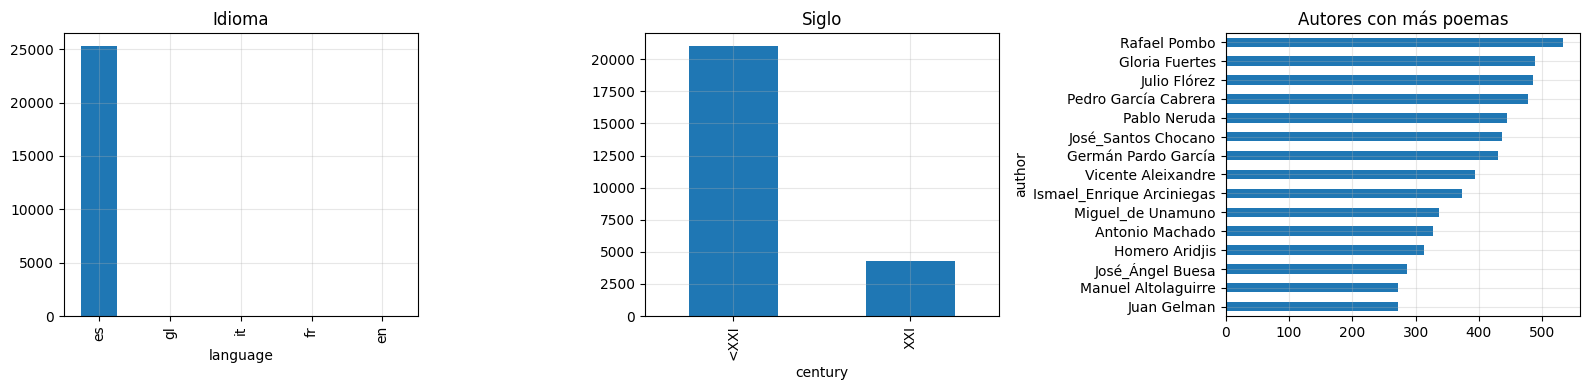

859 autores | mediana de poemas por autor: 7 | los 10 autores principales concentran 17.4% del corpus


In [ ]:
def roman(s):                          # para ordenar los siglos (XV < XIX < XXI)
    vals = {"I": 1, "V": 5, "X": 10, "L": 50, "C": 100}
    total, prev = 0, 0
    for ch in reversed(str(s)):
        v = vals.get(ch, 0)
        total += -v if v < prev else v
        prev = v
    return total

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
df["language"].value_counts(dropna=False).head(8).plot.bar(ax=ax[0], title="Idioma")
cent = df["century"].value_counts()
cent.reindex(sorted(cent.index, key=roman)).plot.bar(ax=ax[1], title="Siglo")
df["author"].value_counts().head(15).sort_values().plot.barh(ax=ax[2], title="Autores con más poemas")
plt.tight_layout()
plt.show()

vc = df["author"].value_counts()
print(f"{len(vc):,} autores | mediana de poemas por autor: {vc.median():.0f} | los 10 autores principales concentran {vc.head(10).sum() / len(df):.1%} del corpus")

Casi todos los poemas están en español (solo 27 de 25.300 no lo están). El 83% es anterior al siglo XXI (la columna `century` solo distingue `<XXI` y `XXI`), así que el lenguaje probablemente es más clásico que el de hoy. Hay 859 autores, con una mediana de 7 poemas por autor; los 10 con más poemas suman solo 17,4% del corpus, así que ningún autor domina.

### 1.3 Longitud y forma
Lo que distingue a un poema de un párrafo es su forma: muchos saltos de línea y versos cortos. Medimos caracteres, versos, palabras por verso y estrofas (bloques separados por una línea en blanco). Las líneas rojas marcan los límites de longitud que usaremos como filtro.

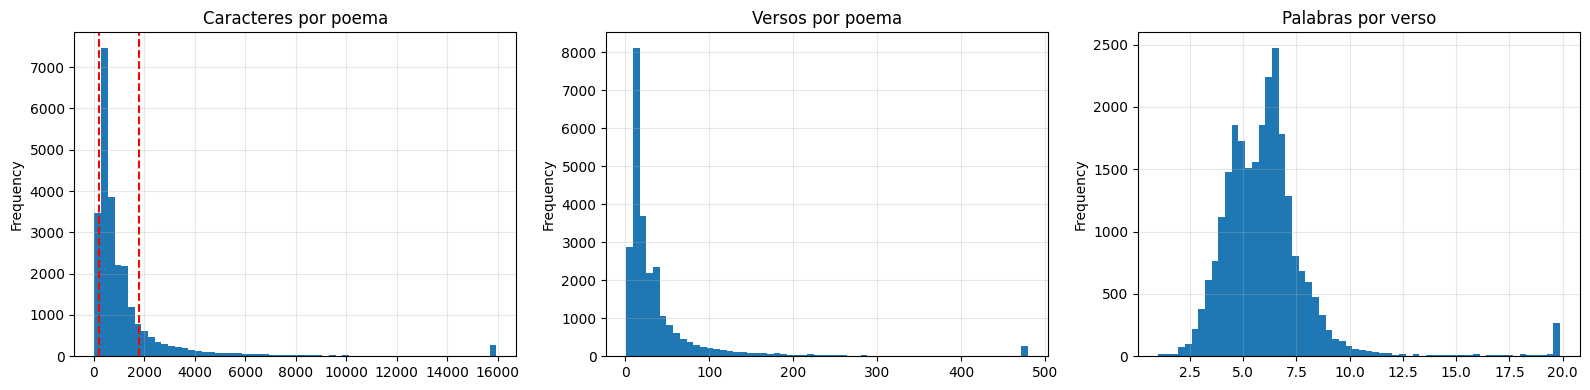

,n_chars,n_lines,n_words,words_per_line,n_stanzas
count,25300.0,25300.0,25300.0,25300.0,25300.0
mean,1767.0,54.5,314.8,6.2,2.2
std,12422.0,406.2,2139.5,4.1,6.6
min,22.0,1.0,4.0,1.0,1.0
5%,146.0,5.0,27.0,3.4,1.0
25%,445.0,14.0,79.0,4.7,1.0
50%,642.0,20.0,116.0,5.9,1.0
75%,1308.0,40.0,236.0,6.8,1.0
95%,4848.2,144.0,865.0,9.0,7.0
max,1451898.0,43609.0,249272.0,156.0,797.0


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, col, title in zip(ax, ["n_chars", "n_lines", "words_per_line"],
                         ["Caracteres por poema", "Versos por poema", "Palabras por verso"]):
    df[col].clip(upper=df[col].quantile(0.99)).plot.hist(bins=60, ax=a, title=title)
ax[0].axvline(MIN_CHARS, color="r", ls="--")
ax[0].axvline(MAX_CHARS, color="r", ls="--")
plt.tight_layout()
plt.show()

df[["n_chars", "n_lines", "n_words", "words_per_line", "n_stanzas"]].describe(percentiles=[.05, .25, .5, .75, .95]).round(1)

In [ ]:
# ¿Cambia la forma según la época?
g = df.groupby("century")[["n_chars", "n_lines", "words_per_line"]].median()
g["poemas"] = df["century"].value_counts()
g.reindex(sorted(g.index, key=roman)).round(1)

,n_chars,n_lines,words_per_line,poemas
century,,,,
<XXI,642.0,20.0,6.0,20999
XXI,644.0,21.0,5.2,4301


### 1.4 Filtros y limpieza
Casi todos los poemas están en español, así que el idioma casi no filtra (solo salen 27). Nos quedamos con poemas de entre 200 y 1800 caracteres: los más cortos (1.974) dan poco contexto y los muy largos (4.325, hasta 1,4 millones de caracteres) no caben bien en el modelo y encarecen el entrenamiento. Exigimos al menos 4 versos para descartar prosa o entradas mal cortadas (519), y eliminamos duplicados exactos para que un poema no quede a la vez en entrenamiento y en evaluación. Quedan **18.915 poemas (75%)**.

In [ ]:
no_es   = df["language"] != "es"
short   = df["n_chars"] < MIN_CHARS
long_   = df["n_chars"] > MAX_CHARS
few_lin = df["n_lines"] < MIN_LINES
keep = ~(no_es | short | long_ | few_lin)
dups = df[keep].duplicated("text", keep="first")

print(f"Total: {len(df):,}")
for name, m in [("no español", no_es), ("muy cortos", short), ("muy largos", long_), (f"< {MIN_LINES} versos", few_lin)]:
    print(f"  {name:<14}: {m.sum():>6,}   (las categorías se solapan)")
print(f"  duplicados    : {dups.sum():>6,}   (entre los que pasan los demás filtros)")

dfc = df[keep].drop_duplicates("text").reset_index(drop=True)
dfc["doc"] = dfc["title"] + "\n\n" + dfc["text"]     # así verá cada poema el modelo: título, línea en blanco, versos
print(f"\nQuedan {len(dfc):,} poemas ({len(dfc) / len(df):.0%} del corpus)")
print(dfc["doc"].iloc[0])

Total: 25,300
  no español    :     27   (las categorías se solapan)
  muy cortos    :  1,974   (las categorías se solapan)
  muy largos    :  4,325   (las categorías se solapan)
  < 4 versos    :    519   (las categorías se solapan)
  duplicados    :      3   (entre los que pasan los demás filtros)

Quedan 18,915 poemas (75% del corpus)
A Neruda

A ese poeta que nació en mi tierra,
que escribió al mar
y a las estrellas,
que navegó los mares
para inspirar su pluma,
para buscar la musa
que guiara sus letras.
A ese poeta que le gritó al viento
todo el amor en cien sonetos,
que se inspiró en la vida
de su humilde pueblo,
que murió de pena al verlo muerto.
A ese poeta de la Isla Negra
que recorrió el mundo
sin olvidar su tierra,
a ese capitán de aquellos versos
que lo casó la luna
rodeada de estrellas.
A ese poeta le debo estos versos,
a ese gran hombre
dedico estas letras.


### 1.5 Vocabulario
Revisamos las palabras más frecuentes (sin stopwords), la ley de Zipf y la riqueza léxica por poema (*type-token ratio*: palabras distintas / palabras totales) según el siglo. Sirve para ver si hay épocas con un lenguaje muy distinto al español con el que se pre-entrenaron los modelos.

Palabras totales: 2,475,876 | vocabulario: 85,418 | hapax: 43% del vocabulario


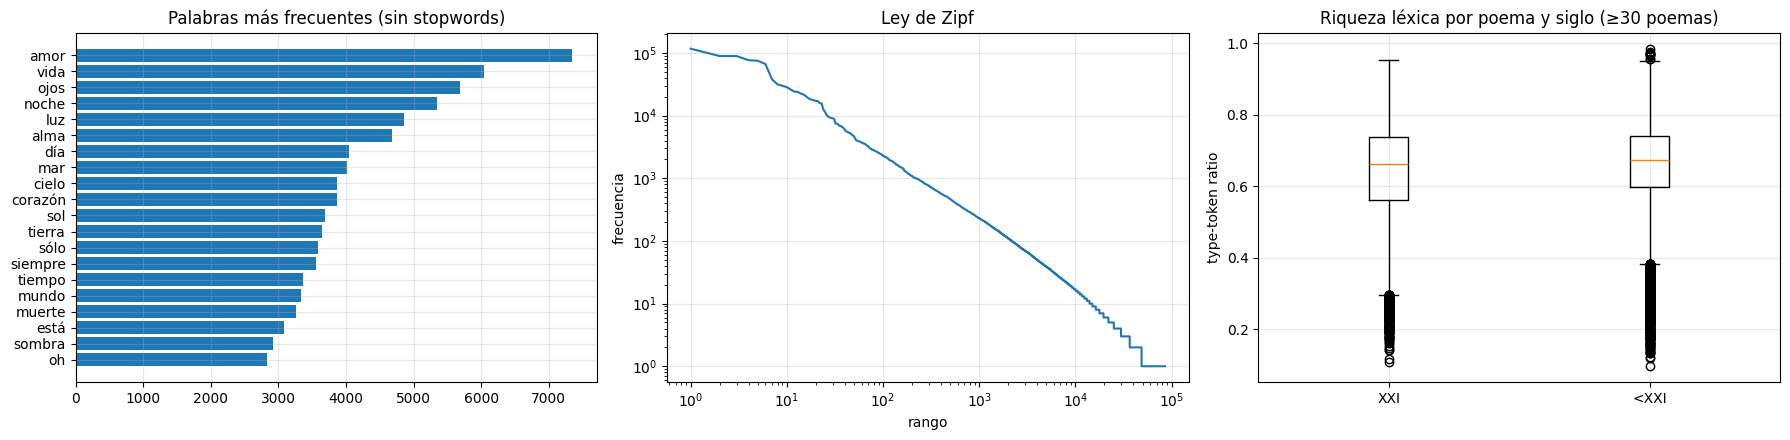

In [ ]:
STOP = set("de la que el en y a los del se las por un para con no una su al lo como más pero sus le ya o este sí porque esta entre cuando muy sin sobre también me hasta hay donde quien desde todo nos todos uno les ni contra otros ese eso ante ellos e esto mí antes algunos qué unos yo otro otras otra él tanto esa estos mucho nada ella mi mis tú te ti tu tus es son ha han era fue ser si tan he ve va".split())
WORD = re.compile(r"[a-záéíóúüñ]+")

cnt = Counter(w for t in dfc["text"] for w in WORD.findall(t.lower()))
hapax = sum(1 for c in cnt.values() if c == 1)
print(f"Palabras totales: {sum(cnt.values()):,} | vocabulario: {len(cnt):,} | hapax: {hapax / len(cnt):.0%} del vocabulario")

top = [(w, c) for w, c in cnt.most_common(200) if w not in STOP][:20]
freqs = np.array(sorted(cnt.values(), reverse=True))

dfc["ttr"] = dfc["text"].map(lambda t: (lambda w: len(set(w)) / max(len(w), 1))(WORD.findall(t.lower())))
order = [c for c in sorted(dfc["century"].dropna().unique(), key=roman) if (dfc["century"] == c).sum() >= 30]

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
ax[0].barh([w for w, _ in top][::-1], [c for _, c in top][::-1])
ax[0].set_title("Palabras más frecuentes (sin stopwords)")
ax[1].loglog(np.arange(1, len(freqs) + 1), freqs)
ax[1].set(title="Ley de Zipf", xlabel="rango", ylabel="frecuencia")
ax[2].boxplot([dfc.loc[dfc["century"] == c, "ttr"] for c in order])
ax[2].set_xticklabels(order)
ax[2].set(title="Riqueza léxica por poema y siglo (≥30 poemas)", ylabel="type-token ratio")
plt.tight_layout()
plt.show()

### 1.6 Forma: rima y repetición (heurística)
Definimos `style_metrics`, que también usaremos para evaluar las generaciones:

* `n_lines` y `words_per_line`: cuántos versos y qué tan largos. Un párrafo de prosa tiene pocas líneas y muy largas.
* `distinct2`: proporción de bigramas distintos (baja si el texto se repite).
* `repeated_lines`: proporción de versos que son copia exacta de otro.
* `rhyme_rate`: fracción de pares de versos vecinos (distancia 1 o 2) cuyas últimas 3 letras coinciden, sin contar la misma palabra repetida.

Es una aproximación (no separa sílabas ni distingue rima asonante de consonante y la poesía moderna suele ser verso libre), pero es barata y permite comparar poemas reales con generaciones.

{'n_lines': 21, 'words_per_line': 5.0476190476190474, 'distinct2': 0.9142857142857143, 'repeated_lines': 0.0, 'rhyme_rate': 0.0}


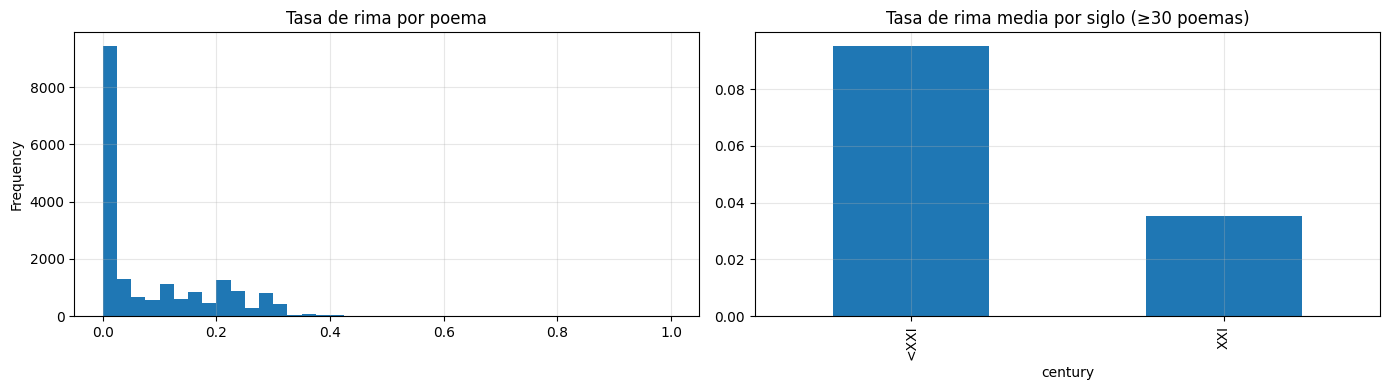

,m_n_lines,m_words_per_line,m_distinct2,m_repeated_lines,m_rhyme_rate
count,18915.000,18915.000,18915.000,18915.000,18915.000
mean,22.847,6.073,0.890,0.070,0.085
std,13.512,2.202,0.171,0.176,0.109
min,4.000,1.379,0.165,0.000,0.000
25%,14.000,4.833,0.903,0.000,0.000
50%,18.000,6.000,0.957,0.000,0.026
75%,30.000,6.800,0.981,0.000,0.160
max,135.000,43.750,1.000,0.847,1.000


In [ ]:
WORD = re.compile(r"[a-záéíóúüñ]+")     # (ya definido en 1.5; se repite para que esta celda sea autosuficiente)

def _words(line):
    return WORD.findall(line.lower())

def _strip_acc(s):
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")

def style_metrics(body):
    lines = [l.strip() for l in body.split("\n") if l.strip()]
    if not lines:
        return dict(n_lines=0, words_per_line=0.0, distinct2=0.0, repeated_lines=0.0, rhyme_rate=0.0)
    words_per = [len(_words(l)) for l in lines]
    allw = [w for l in lines for w in _words(l)]
    bigr = list(zip(allw, allw[1:]))
    last = [_strip_acc(_words(l)[-1]) if _words(l) else "" for l in lines]
    pairs = [(i, i + d) for d in (1, 2) for i in range(len(lines) - d)]
    rh = [1 if (len(last[i]) >= 3 and last[i][-3:] == last[j][-3:] and last[i] != last[j]) else 0 for i, j in pairs]
    return dict(
        n_lines=len(lines),
        words_per_line=float(np.mean(words_per)),
        distinct2=len(set(bigr)) / len(bigr) if bigr else 0.0,
        repeated_lines=1 - len(set(lines)) / len(lines),
        rhyme_rate=float(np.mean(rh)) if rh else 0.0,
    )

print(style_metrics(dfc["text"].iloc[0]))

sm = pd.DataFrame([style_metrics(t) for t in dfc["text"]]).add_prefix("m_")
dfc = pd.concat([dfc, sm], axis=1)

g = dfc.groupby("century")["m_rhyme_rate"].agg(["mean", "count"])
g = g[g["count"] >= 30]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
dfc["m_rhyme_rate"].plot.hist(bins=40, ax=ax[0], title="Tasa de rima por poema")
g["mean"].reindex(sorted(g.index, key=roman)).plot.bar(ax=ax[1], title="Tasa de rima media por siglo (≥30 poemas)")
plt.tight_layout()
plt.show()
dfc[["m_n_lines", "m_words_per_line", "m_distinct2", "m_repeated_lines", "m_rhyme_rate"]].describe().round(3)

### 1.7 Tokenizadores
Un mismo poema se convierte en una cantidad distinta de tokens según el tokenizador. Esto importa por tres razones: el costo de entrenamiento crece con los tokens, los poemas que superan la ventana de contexto se truncan (y pierden su final), y la perplejidad por token **no es comparable** entre modelos con tokenizadores distintos. Por eso más adelante usamos bits por carácter.

In [ ]:
TOK_IDS = {"spanish-gpt2": "mrm8488/spanish-gpt2",
           "DeepESP-gpt2": "DeepESP/gpt2-spanish",
           "Salamandra-2b": "BSC-LT/salamandra-2b"}
sample_docs = dfc["doc"].sample(2000, random_state=SEED).tolist()
chars = np.array([len(d) for d in sample_docs])

rows = []
for name, mid in TOK_IDS.items():
    t = AutoTokenizer.from_pretrained(mid)
    lens = np.array([len(x) for x in t(sample_docs)["input_ids"]])
    rows.append({"tokenizador": name, "vocabulario": len(t), "tokens (mediana)": np.median(lens),
                 "caracteres por token": chars.sum() / lens.sum(),
                 **{f"% > {L} tokens": (lens > L).mean() * 100 for L in (256, 384, 512, 1024)}})
pd.DataFrame(rows).set_index("tokenizador").round(1)

config.json:   0%|          | 0.00/883 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/226 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/846k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/505k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

...

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 37.0MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

,vocabulario,tokens (mediana),caracteres por token,% > 256 tokens,% > 384 tokens,% > 512 tokens,% > 1024 tokens
tokenizador,,,,,,,
spanish-gpt2,50266,173.0,3.6,29.5,9.6,0.9,0.0
DeepESP-gpt2,50257,172.0,3.6,29.1,9.4,0.8,0.0
Salamandra-2b,256000,192.0,3.2,34.2,14.2,3.1,0.0


### 1.8 Partición entrenamiento / evaluación
Reservamos 5% de los poemas para evaluación (y usamos `N_EVAL` de ellos para medir bits por carácter). También calculamos las métricas de estilo de los **poemas reales** del conjunto de evaluación, que serán nuestra referencia. Como las generaciones tienen un largo limitado, comparamos solo los primeros `CMP_CHARS` caracteres de cada texto.

In [ ]:
dfc = dfc.sample(frac=1, random_state=SEED).reset_index(drop=True)
n_test = int(len(dfc) * TEST_FRAC)
test_df, train_df = dfc.iloc[:n_test], dfc.iloc[n_test:]

train_docs = train_df["doc"].tolist()
eval_docs = test_df["doc"].tolist()[:N_EVAL]
ref_style = pd.DataFrame([style_metrics(t[:CMP_CHARS]) for t in test_df["text"].tolist()[:N_EVAL]]).mean().to_dict()

print(f"Entrenamiento: {len(train_docs):,} | evaluación: {n_test:,} (se usan {len(eval_docs)})")
print("Estilo de los poemas reales (referencia):", {k: round(v, 3) for k, v in ref_style.items()})

Entrenamiento: 17,970 | evaluación: 945 (se usan 300)
Estilo de los poemas reales (referencia): {'n_lines': 14.863, 'words_per_line': 5.833, 'distinct2': 0.946, 'repeated_lines': 0.016, 'rhyme_rate': 0.087}


### Hallazgos del EDA
* **Composición:** 25.300 poemas de 859 autores. El 83% es anterior al siglo XXI y ningún autor domina (los 10 principales suman 17,4%).
* **Forma:** un poema típico tiene ~20 versos de ~6 palabras y una sola estrofa. La forma es parecida entre épocas (medianas de 642 y 644 caracteres); los poemas del siglo XXI tienen versos algo más cortos (5,2 contra 6,0 palabras).
* **Vocabulario:** 2,5 millones de palabras y 85 mil distintas; el 43% aparece una sola vez. Las más comunes son temas clásicos (amor, vida, ojos, noche, luz, alma). La riqueza léxica por poema es parecida en las dos épocas.
* **Rima:** es poco frecuente con nuestra medida: media de 8,5% y la mitad de los poemas tiene 2,6% o menos. Es mayor antes del siglo XXI (9,5%) que en el XXI (3,5%), lo que encaja con el verso libre moderno.
* **Tokenización:** un poema mediano son ~173 tokens con los GPT-2 y ~192 con Salamandra. Con `max_len=512` se trunca menos del 1% de los poemas (3,1% en Salamandra).
* **Implicación:** el corpus es grande y de versos cortos. Lo que más debería cambiar en el modelo es la forma (versos cortos y saltos de línea); la rima es poco frecuente, así que no es lo esperable.

## 2. Estrategia de comparación

| Modelo | Arquitectura | Pre-entrenamiento | Tokenizador | Fine-tuning |
|---|---|---|---|---|
| spanish-gpt2 | GPT-2 small (~124M) | desde cero, ~20 GB de corpus general en español | BPE propio en español | completo |
| DeepESP/gpt2-spanish | GPT-2 small (~124M) | desde cero, 11,5 GB (3,5 GB Wikipedia + 8 GB de libros) | BPE propio en español (50.257) | completo |
| Salamandra-2B | decoder tipo Llama (~2B) | multilingüe (35 idiomas) | propio, multilingüe | LoRA |
| GPT-2 desde cero | GPT-2 pequeño (6 capas) | ninguno | BPE de 16k entrenado en los poemas | completo, con todo el corpus |

**Cómo evaluamos** (mismos poemas de evaluación y mismos prompts para todos):

1. **Bits por carácter (bpc)** sobre poemas no vistos: pérdida total del modelo dividida entre el número de caracteres del poema. Es una perplejidad normalizada por carácter, así que sí es comparable entre tokenizadores distintos (la perplejidad por token no lo es). Menor es mejor.
2. **Métricas de estilo** de las generaciones (`style_metrics`) contra la referencia de poemas reales: versos, palabras por verso, repetición y rima.
3. **Lectura directa** de las generaciones, antes y después del fine-tuning, y una comparación de estrategias de decodificación.

Cada modelo genera con el prompt `<título>\n\n`, que es exactamente el formato con el que se entrena (`título`, línea en blanco, versos, `<eos>`). Los modelos GPT-2 usan `<|endoftext|>` como marca de inicio y de fin de poema; Salamandra usa su `<s>` y `</s>`.

## 3. Utilidades
Funciones compartidas por los cuatro experimentos: formato y tokenización, *collator* (la pérdida no se calcula sobre el relleno, pero sí sobre el `<eos>` final para que el modelo aprenda a cerrar el poema), bits por carácter, generación y el flujo completo de un experimento (evaluar el modelo base → entrenar → evaluar de nuevo).

In [ ]:
DEFAULT_GEN = dict(do_sample=True, temperature=0.9, top_p=0.92)
DECODING = {   # se prueban solo después del fine-tuning
    "greedy": dict(do_sample=False),
    "muestreo + anti-repetición": dict(do_sample=True, temperature=0.8, top_p=0.92, repetition_penalty=1.2, no_repeat_ngram_size=3),
    "muestreo caliente (T=1.3)": dict(do_sample=True, temperature=1.3, top_p=0.98),
}
DEFAULT_NAME = "muestreo base (T=0.9, top_p=0.92)"

def slug(name):
    return re.sub(r"[^A-Za-z0-9]+", "-", name).strip("-")

def make_collator(pad_id):
    def collate(batch):
        n = max(len(b["input_ids"]) for b in batch)
        ids = torch.full((len(batch), n), pad_id, dtype=torch.long)
        att = torch.zeros((len(batch), n), dtype=torch.long)
        for i, b in enumerate(batch):
            l = len(b["input_ids"])
            ids[i, :l] = torch.tensor(b["input_ids"])
            att[i, :l] = 1
        labels = ids.clone()
        labels[att == 0] = -100          # sin pérdida sobre el relleno (el <eos> final sí cuenta)
        return {"input_ids": ids, "attention_mask": att, "labels": labels}
    return collate

def encode_docs(docs, tok, max_len, prefix):
    enc = tok([prefix + d + tok.eos_token for d in docs], truncation=True, max_length=max_len)["input_ids"]
    return [{"input_ids": ids} for ids in enc]

@torch.no_grad()
def bits_per_char(model, tok, docs, max_len, prefix):
    model.eval()
    tot_nll, tot_chars = 0.0, 0
    for d in docs:
        ids = tok(prefix + d + tok.eos_token, return_tensors="pt", truncation=True, max_length=max_len)["input_ids"].to(device)
        loss = model(input_ids=ids, labels=ids).loss.item()      # promedio por token predicho
        tot_nll += loss * (ids.shape[1] - 1)
        tot_chars += len(d)
    return tot_nll / tot_chars / math.log(2)

@torch.no_grad()
def sample_poems(model, tok, prompts, prefix, gen_kwargs, n=N_SAMPLES, seed=SEED):
    model.eval()
    n_eff = n if gen_kwargs.get("do_sample", False) else 1     # greedy es determinista: una sola muestra
    out_list = []
    for p in prompts:
        set_seed(seed)
        enc = tok(prefix + p + "\n\n", return_tensors="pt")
        ids, att = enc["input_ids"].to(device), enc["attention_mask"].to(device)
        out = model.generate(input_ids=ids, attention_mask=att, max_new_tokens=MAX_NEW_TOKENS,
                             num_return_sequences=n_eff, pad_token_id=tok.pad_token_id,
                             eos_token_id=tok.eos_token_id, **gen_kwargs)
        for seq in out:
            gen = seq[ids.shape[1]:]
            out_list.append(dict(prompt=p, closed=bool((gen == tok.eos_token_id).any()),
                                 body=tok.decode(gen, skip_special_tokens=True).strip()))
    return out_list

def agg_style(samples):
    rows = [{**style_metrics(s["body"][:CMP_CHARS]), "closed": float(s["closed"])} for s in samples]
    return pd.DataFrame(rows).mean().to_dict()

def count_params(m):
    return sum(p.numel() for p in m.parameters()), sum(p.numel() for p in m.parameters() if p.requires_grad)

In [ ]:
from tokenizers import ByteLevelBPETokenizer

CONFIGS = {
    # Fine-tuning completo de GPT-2 small. 'prefix="eos"': cada poema empieza con <|endoftext|>.
    "spanish-gpt2":  dict(kind="gpt2", model_id="mrm8488/spanish-gpt2", prefix="eos",
                          epochs=3, lr=5e-5, bs=16, ga=1, max_len=512, n_train=N_TRAIN),
    "DeepESP-gpt2":  dict(kind="gpt2", model_id="DeepESP/gpt2-spanish", prefix="eos",
                          epochs=3, lr=5e-5, bs=16, ga=1, max_len=512, n_train=N_TRAIN),
    # LoRA sobre Salamandra. Su tokenizador ya agrega <s> al inicio, por eso prefix="".
    "Salamandra-2b": dict(kind="lora", model_id="BSC-LT/salamandra-2b", prefix="",
                          epochs=2, lr=2e-4, bs=4, ga=4, max_len=512, n_train=N_TRAIN),
    # GPT-2 pequeño sin pre-entrenamiento: tokenizador propio y todo el corpus de entrenamiento.
    "GPT-2 desde cero": dict(kind="scratch", prefix="eos", vocab=16000,
                             epochs=15, lr=6e-4, bs=32, ga=1, max_len=512, n_train=None),
}

def train_bpe_tokenizer(docs, vocab_size):
    bpe = ByteLevelBPETokenizer()
    bpe.train_from_iterator(docs, vocab_size=vocab_size, min_frequency=2, special_tokens=["<|endoftext|>"])
    return PreTrainedTokenizerFast(tokenizer_object=bpe._tokenizer, eos_token="<|endoftext|>",
                                   pad_token="<|endoftext|>", model_input_names=["input_ids", "attention_mask"])

def load_causal(model_id, dtype=None):
    if dtype is None:
        return AutoModelForCausalLM.from_pretrained(model_id)
    try:
        return AutoModelForCausalLM.from_pretrained(model_id, dtype=dtype)           # transformers >= 5
    except (TypeError, ValueError):
        return AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=dtype)     # versiones anteriores

def build_model(cfg):
    kind = cfg["kind"]
    if kind == "scratch":
        tok = train_bpe_tokenizer(train_docs, cfg["vocab"])
        config = GPT2Config(vocab_size=len(tok), n_positions=cfg["max_len"], n_embd=384, n_layer=6, n_head=6,
                            bos_token_id=tok.eos_token_id, eos_token_id=tok.eos_token_id)
        return tok, GPT2LMHeadModel(config).to(device)

    tok = AutoTokenizer.from_pretrained(cfg["model_id"])
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    if kind == "gpt2":
        # fp32 explícito: transformers 5 carga por defecto en el dtype del checkpoint
        model = load_causal(cfg["model_id"], torch.float32).to(device)
        if len(tok) > model.get_input_embeddings().num_embeddings:
            model.resize_token_embeddings(len(tok))
    else:  # LoRA
        from peft import LoraConfig, get_peft_model
        dtype = torch.bfloat16 if use_bf16 else torch.float16
        base = load_causal(cfg["model_id"], dtype).to(device)
        base.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
        base.enable_input_require_grads()
        lora = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, task_type="CAUSAL_LM",
                          target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"])
        model = get_peft_model(base, lora)      # LoRA arranca en cero: antes de entrenar, el modelo equivale al base
        for p in model.parameters():            # los adaptadores se entrenan en fp32 aunque el modelo base esté en fp16
            if p.requires_grad:
                p.data = p.data.float()
    model.config.pad_token_id = tok.pad_token_id
    return tok, model

In [ ]:
def run_experiment(name, cfg):
    path = f"{OUT_DIR}/{slug(name)}.json"
    if os.path.exists(path):
        print("Resultado guardado encontrado, se carga sin reentrenar:", path)
        with open(path, encoding="utf-8") as f:
            return json.load(f)

    set_seed(SEED)
    tok, model = build_model(cfg)
    prefix = tok.eos_token if cfg["prefix"] == "eos" else ""
    res = dict(name=name, model_id=cfg.get("model_id", "(desde cero)"), config={k: v for k, v in cfg.items() if k != "kind"})
    res["params_total"], res["params_trainable"] = count_params(model)

    train_enc = encode_docs(train_docs[:cfg["n_train"]] if cfg["n_train"] else train_docs, tok, cfg["max_len"], prefix)
    eval_enc = encode_docs(eval_docs, tok, cfg["max_len"], prefix)
    res["n_train"] = len(train_enc)
    res["truncated_pct"] = float(np.mean([len(e["input_ids"]) >= cfg["max_len"] for e in train_enc]))
    print(f"[{name}] {res['params_total'] / 1e6:.0f}M parámetros ({res['params_trainable'] / 1e6:.1f}M entrenables) | "
          f"{len(train_enc):,} poemas de entrenamiento | truncados: {res['truncated_pct']:.1%}")

    # 1) Modelo base, antes de entrenar (el modelo desde cero no tiene "antes": sus pesos son aleatorios)
    if cfg["kind"] != "scratch":
        res["bpc_before"] = bits_per_char(model, tok, eval_docs, cfg["max_len"], prefix)
        samples = sample_poems(model, tok, PROMPTS, prefix, DEFAULT_GEN)
        res["samples_before"], res["style_before"] = samples, agg_style(samples)
        print(f"[{name}] bpc antes: {res['bpc_before']:.3f}")

    # 2) Entrenamiento
    steps_per_epoch = math.ceil(len(train_enc) / (cfg["bs"] * cfg["ga"]))
    args = TrainingArguments(
        output_dir=f"./hf-{slug(name)}", num_train_epochs=cfg["epochs"], learning_rate=cfg["lr"],
        per_device_train_batch_size=cfg["bs"], per_device_eval_batch_size=cfg["bs"],
        gradient_accumulation_steps=cfg["ga"], weight_decay=0.01, lr_scheduler_type="cosine",
        warmup_steps=int(0.05 * steps_per_epoch * cfg["epochs"]),
        eval_strategy="epoch", save_strategy="no", logging_steps=max(1, steps_per_epoch // 4),
        fp16=(device == "cuda" and not use_bf16), bf16=use_bf16,
        remove_unused_columns=False, label_names=["labels"], report_to="none", seed=SEED)
    trainer = Trainer(model=model, args=args, train_dataset=train_enc, eval_dataset=eval_enc,
                      data_collator=make_collator(tok.pad_token_id))
    if cfg["kind"] == "lora":
        model.config.use_cache = False
    t0 = time.time()
    trainer.train()
    res["train_minutes"] = (time.time() - t0) / 60
    res["history"] = trainer.state.log_history
    if cfg["kind"] == "lora":
        model.config.use_cache = True

    # 3) Modelo entrenado
    res["bpc_after"] = bits_per_char(model, tok, eval_docs, cfg["max_len"], prefix)
    if not math.isfinite(res["bpc_after"]):
      raise RuntimeError(f"[{name}] el entrenamiento divergió (bpc = NaN/inf).")
    samples = sample_poems(model, tok, PROMPTS, prefix, DEFAULT_GEN)
    res["samples_after"], res["style_after"] = samples, agg_style(samples)
    res["decoding"] = {DEFAULT_NAME: res["style_after"]}
    res["decoding_samples"] = {DEFAULT_NAME: samples[0]["body"]}
    for k, kw in DECODING.items():
        s = sample_poems(model, tok, PROMPTS[:4], prefix, kw)
        res["decoding"][k] = agg_style(s)
        res["decoding_samples"][k] = s[0]["body"]
    print(f"[{name}] bpc después: {res['bpc_after']:.3f} | entrenamiento: {res['train_minutes']:.1f} min")

    with open(path, "w", encoding="utf-8") as f:
        json.dump(res, f, ensure_ascii=False, default=float)
    del model, trainer
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()
    return res

def show(res, prompt_idx=0):
    b = f"{res['bpc_before']:.3f} → " if "bpc_before" in res else "(sin modelo base) "
    print(f"{res['name']} | {res['params_total'] / 1e6:.0f}M params ({res['params_trainable'] / 1e6:.1f}M entrenables) | "
          f"bpc {b}{res['bpc_after']:.3f} | {res['train_minutes']:.1f} min | poemas truncados: {res['truncated_pct']:.1%}")
    i = prompt_idx * N_SAMPLES
    if "samples_before" in res:
        print(f"\n--- BASE · prompt: '{PROMPTS[prompt_idx]}' ---\n{res['samples_before'][i]['body'][:500]}")
    print(f"\n--- FINE-TUNED · prompt: '{PROMPTS[prompt_idx]}' ---\n{res['samples_after'][i]['body'][:500]}")

## 4. Experimento 1 · spanish-gpt2
spanish-gpt2 es un GPT-2 small entrenado con ~20 GB de texto general en español. Fine-tuning completo: 3 épocas, `lr=5e-5`, `max_len=512`, con los primeros `N_TRAIN` poemas.

**Hipótesis:** antes de entrenar, el modelo escribe texto corrido (un párrafo largo, sin saltos de línea); después debe producir versos cortos y estrofas. Como su corpus de pre-entrenamiento es general, el cambio debería ser grande.

In [ ]:
res_1 = run_experiment("spanish-gpt2", CONFIGS["spanish-gpt2"])
show(res_1)

model.safetensors: reconstructing file:   0%|          |  0.00B /  510MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


[spanish-gpt2] 124M parámetros (124.4M entrenables) | 5,000 poemas de entrenamiento | truncados: 0.8%


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


[spanish-gpt2] bpc antes: 2.461


Epoch,Training Loss,Validation Loss
1,3.588145,3.546865
2,3.384937,3.453166
3,3.249634,3.443535


[spanish-gpt2] bpc después: 1.391 | entrenamiento: 7.0 min
spanish-gpt2 | 124M params (124.4M entrenables) | bpc 2.461 → 1.391 | 7.0 min | poemas truncados: 0.8%

--- BASE · prompt: 'El mar' ---
CONSEJO (7) — ASUNTOS TÒLlGICOSEl mar (8) — ASUNTOS TÒLlGICOSEl mar (9) — ASUNTOS TÒLlGICOSEl mar (10) — ASUNTOS TÒLlGICOSEl mar (11) — ASUNTOS TÒLlGICOSEl mar (12) — ASUNTOS TÒLlGICOSEl mar (13) — ASUNTOS TÒLlGICOSEl mar (14) — ASUNTOS TÒLlGICOSEl mar (15) — ASUNTOS TÒLlGICOSEl mar (16) — ASUNTOS TÒLlGICOSEl mar (17) — ASUNTOS TÒLlGICOSEl mar (18) — ASUNTOS TÒLlGICOSEl mar (19) — ASUNTOS TÒLlGICOSEl mar (20) — ASUNTOS TÒLlGICOSEl mar (21)

--- FINE-TUNED · prompt: 'El mar' ---
Un mar de amor
En mi playa
Te espera mi sombra,
En el mar
Y yo, mi sombra,
Te espera,
En mi playa,
Te espera mi sombra,
En el mar
Y yo, mi sombra,
Te espera mi sombra,
En el mar
Y yo, mi sombra,
Te espera,
En el mar
Y yo, mi sombra,
Te espera,
En el mar
Y yo, mi sombra,
Te espera,
En el mar
Y yo, mi sombra,
Te espera,
En

## 5. Experimento 2 · DeepESP/gpt2-spanish
Mismo tamaño y mismos hiperparámetros, cambia solo el modelo de partida. Su corpus incluye ~8 GB de libros (narrativa, teatro, poesía, ensayo), así que ya vio literatura.

**Hipótesis:** si el tipo de corpus de pre-entrenamiento importa, este modelo debería tener menos bpc que spanish-gpt2 antes del fine-tuning y converger con mayor facilidad.

In [ ]:
res_2 = run_experiment("DeepESP-gpt2", CONFIGS["DeepESP-gpt2"])
show(res_2)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  261MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: DeepESP/gpt2-spanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


[DeepESP-gpt2] 124M parámetros (124.4M entrenables) | 5,000 poemas de entrenamiento | truncados: 0.6%


model.safetensors: reconstructing file:   0%|          |  0.00B /  261MB            

model.safetensors: downloading bytes:           |  0.00B            

[DeepESP-gpt2] bpc antes: 1.994


Epoch,Training Loss,Validation Loss
1,3.679115,3.559477
2,3.445030,3.522595
3,3.254927,3.523688


[DeepESP-gpt2] bpc después: 1.414 | entrenamiento: 7.6 min
DeepESP-gpt2 | 124M params (124.4M entrenables) | bpc 1.994 → 1.414 | 7.6 min | poemas truncados: 0.6%

--- BASE · prompt: 'El mar' ---
A pesar de la gravedad del océano, los océanos son aún más fríos y turbulentos que los océanos, pero los mares son más áridos. 

Las nubes y las mareas pueden ser visibles desde la superficie, mientras que las nubes más altas pueden aparecer en el cielo. El mar, el Sol y la Tierra pueden verse desde el cielo, aunque sólo se hallan en las alturas, con lo que no puede pasar mucho tiempo antes de que se produzca la mayor inundación. El mar es grande, y las nubes pueden verse desde las nubes. 

Los 

--- FINE-TUNED · prompt: 'El mar' ---
A pesar de la calma,
como los mares al fondo,
de la mar que flota
hacia el Norte
no se ve,
ni un cielo sereno.
Negro y amarillo,
sueño azul de un cielo que no alcanza
a la tierra.
Ni un mar azul.
Ni un mar azul.
Ni un mar azul.
Ni un mar azul.
Ni un mar azul.
Ni un

## 6. Experimento 3 · Salamandra-2B con LoRA
Un modelo unas 15-20 veces más grande que los GPT-2 small. El fine-tuning completo no cabe en los 24 GB de una L4, así que usamos **LoRA**: se congelan los pesos originales y se entrenan matrices de bajo rango (`r=16`) inyectadas en las proyecciones de atención y del MLP, una fracción muy pequeña de los parámetros (la celda imprime el número exacto). Como los adaptadores arrancan en cero, antes de entrenar el modelo equivale al base. Usamos gradient checkpointing y acumulación de gradiente (batch efectivo de 16) para que quepa en memoria.

**Hipótesis:** el modelo más grande tendrá mejor bpc y textos más coherentes, pero con LoRA y pocas épocas el cambio de *estilo* podría ser menos radical que en el fine-tuning completo.

*Si aparece un error de memoria (CUDA out of memory), baja `bs` a 2 y sube `ga` a 8 en `CONFIGS`.*

In [ ]:
res_3 = run_experiment("Salamandra-2b", CONFIGS["Salamandra-2b"])
show(res_3)

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.51GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

[Salamandra-2b] 2268M parámetros (14.9M entrenables) | 5,000 poemas de entrenamiento | truncados: 2.9%
[Salamandra-2b] bpc antes: 1.359


Epoch,Training Loss,Validation Loss
1,2.794748,2.808923
2,2.628900,2.805981


[Salamandra-2b] bpc después: 1.225 | entrenamiento: 27.2 min
Salamandra-2b | 2268M params (14.9M entrenables) | bpc 1.359 → 1.225 | 27.2 min | poemas truncados: 2.9%

--- BASE · prompt: 'El mar' ---
Sure, here's a short paragraph:
Rudra is feeling relaxed after walking on the beach. He enjoyed being in nature and listening to the sound of waves crashing against shore.

--- FINE-TUNED · prompt: 'El mar' ---
¡Qué hermosa era la playa! Era de una arena tan fina, que se sentía al pisar con cuidado; y en el cielo azul brillaba la luz como un oro puro. Las olas, que venían hacia ti ardiendo del fondo del mar, te hacías mirar hermosísimas como estrellas muertas...
Y no sólo eras bella tú: eran bellas las rocas, los árboles muertos de la playa, y la luna blanca, casi negra sobre ellos... Y la noche estaba estrellada....


## 7. Experimento 4 · GPT-2 desde cero (control)
Es viable como *control*, no como competidor. Un modelo con ~20-30M parámetros y un tokenizador BPE de 16k entrenado solo con poemas cuesta pocos minutos por época. Con unos pocos millones de tokens no puede aprender español de verdad, así que esperamos que aprenda rápido la **forma** (saltos de línea, largo de verso) pero que su vocabulario y coherencia sean pobres, y que su bpc sea peor que el de los modelos pre-entrenados.

El modelo desde cero usa **todo el corpus de entrenamiento** (17.970 poemas en vez de 5.000), una ventaja intencional porque no tiene pre-entrenamiento. Si aun así pierde, el efecto del pre-entrenamiento queda aislado con mucha más claridad. Como no tiene modelo base, no hay medición "antes".

In [ ]:
res_4 = run_experiment("GPT-2 desde cero", CONFIGS["GPT-2 desde cero"])
show(res_4)

[GPT-2 desde cero] 17M parámetros (17.0M entrenables) | 17,970 poemas de entrenamiento | truncados: 0.6%


Epoch,Training Loss,Validation Loss
1,5.408708,5.253369
2,4.943555,4.825954
3,4.584219,4.469445
4,4.264836,4.237801
5,4.022259,4.080154
6,3.887896,3.992310
7,3.797989,3.942652
8,3.667761,3.913294
9,3.586858,3.895931
10,3.514263,3.883734


[GPT-2 desde cero] bpc después: 1.575 | entrenamiento: 32.6 min
GPT-2 desde cero | 17M params (17.0M entrenables) | bpc (sin modelo base) 1.575 | 32.6 min | poemas truncados: 0.6%

--- FINE-TUNED · prompt: 'El mar' ---
El mar,
de la tierra,
en el agua.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar.
el mar


## 8. Resultados
Cargamos los resultados guardados de cada experimento

In [ ]:
RESULTS = {}
for n in CONFIGS:
    p = f"{OUT_DIR}/{slug(n)}.json"
    if os.path.exists(p):
        with open(p, encoding="utf-8") as f:
            RESULTS[n] = json.load(f)

summary = pd.DataFrame([{
    "modelo": n, "params (M)": r["params_total"] / 1e6, "entrenables (M)": r["params_trainable"] / 1e6,
    "poemas de entrenamiento": r["n_train"], "bpc antes": r.get("bpc_before", np.nan), "bpc después": r["bpc_after"],
    "min de entrenamiento": r["train_minutes"], "% truncados": r["truncated_pct"] * 100,
} for n, r in RESULTS.items()]).set_index("modelo").round(3)
summary

,params (M),entrenables (M),poemas de entrenamiento,bpc antes,bpc después,min de entrenamiento,% truncados
modelo,,,,,,,
spanish-gpt2,124.447,124.447,5000,2.461,1.391,7.042,0.760
DeepESP-gpt2,124.440,124.440,5000,1.994,1.414,7.571,0.640
Salamandra-2b,2268.408,14.918,5000,1.359,1.225,27.178,2.860
GPT-2 desde cero,16.988,16.988,17970,NaN,1.575,32.571,0.595


### 8.1 Bits por carácter
La diferencia entre "antes" y "después" mide cuánto aprendió el modelo sobre poemas; la barra "después" compara los cuatro modelos entre sí.

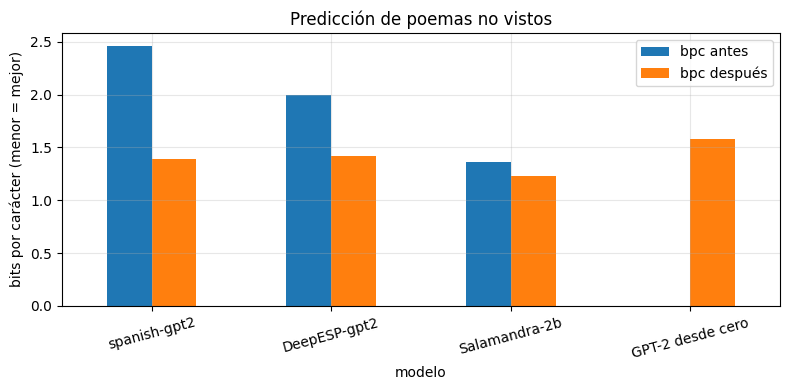

In [ ]:
ax = summary[["bpc antes", "bpc después"]].plot.bar(figsize=(8, 4), rot=15)
ax.set_ylabel("bits por carácter (menor = mejor)")
ax.set_title("Predicción de poemas no vistos")
plt.tight_layout()
plt.show()

### 8.2 Curvas de entrenamiento
Pérdida por token en cada época. Cada panel tiene su propia escala (los tokenizadores son distintos, así que las magnitudes no se comparan entre paneles); sirve para ver si el modelo sigue mejorando o empieza a sobreajustar.

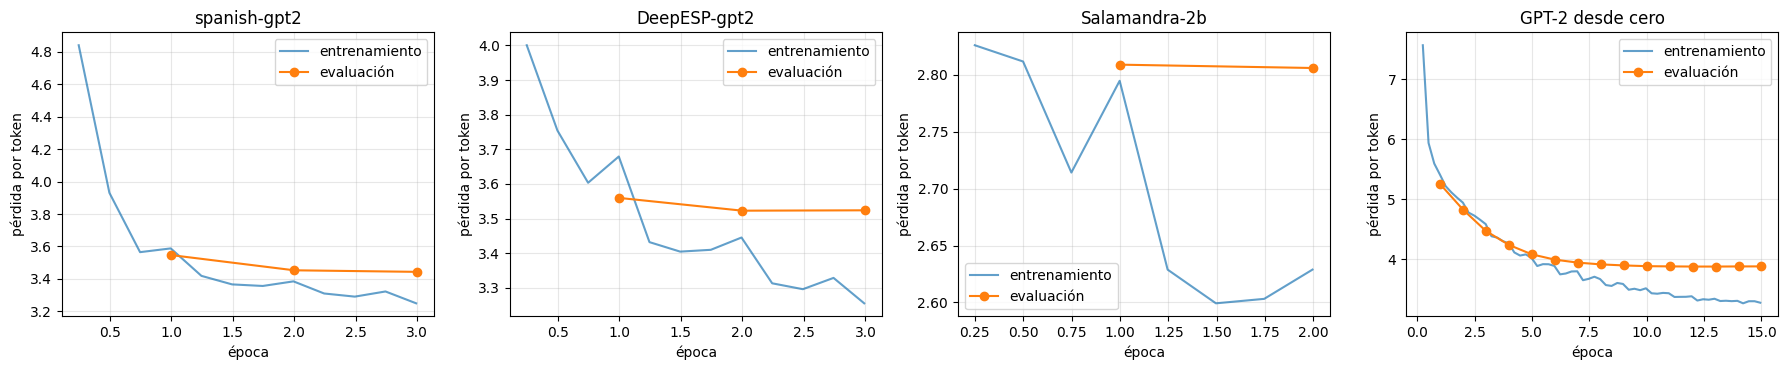

In [ ]:
fig, axes = plt.subplots(1, len(RESULTS), figsize=(4.5 * len(RESULTS), 3.8), squeeze=False)
for ax, (n, r) in zip(axes[0], RESULTS.items()):
    tr = [(h["epoch"], h["loss"]) for h in r["history"] if "loss" in h and "eval_loss" not in h]
    ev = [(h["epoch"], h["eval_loss"]) for h in r["history"] if "eval_loss" in h]
    if tr: ax.plot(*zip(*tr), label="entrenamiento", alpha=0.7)
    if ev: ax.plot(*zip(*ev), marker="o", label="evaluación")
    ax.set(title=n, xlabel="época", ylabel="pérdida por token")
    ax.legend()
plt.tight_layout()
plt.show()

### 8.3 Métricas de estilo
Promedio sobre todas las generaciones (prompts × muestras) contra los poemas reales del conjunto de evaluación (barra negra). Lo esperado de un modelo que aprendió el estilo: `words_per_line` y `n_lines` cerca de la referencia (verso corto, varios versos), `distinct2` alto y `repeated_lines` bajo (sin bucles), y `closed` (la generación terminó con `<eos>` dentro del límite de tokens) más alto después del fine-tuning.

,n_lines,words_per_line,distinct2,repeated_lines,rhyme_rate,closed
Poemas reales,14.863,5.833,0.946,0.016,0.087,NaN
spanish-gpt2 (base),1.000,62.889,0.409,0.000,0.000,0.000
spanish-gpt2 (fine-tuned),25.556,4.776,0.369,0.489,0.010,0.111
DeepESP-gpt2 (base),4.889,43.362,0.846,0.016,0.000,0.000
DeepESP-gpt2 (fine-tuned),23.278,4.717,0.450,0.384,0.001,0.500
Salamandra-2b (base),1.278,44.630,0.997,0.000,0.000,0.611
Salamandra-2b (fine-tuned),4.944,28.605,0.994,0.000,0.010,0.611
GPT-2 desde cero (fine-tuned),22.778,4.667,0.388,0.460,0.004,0.333


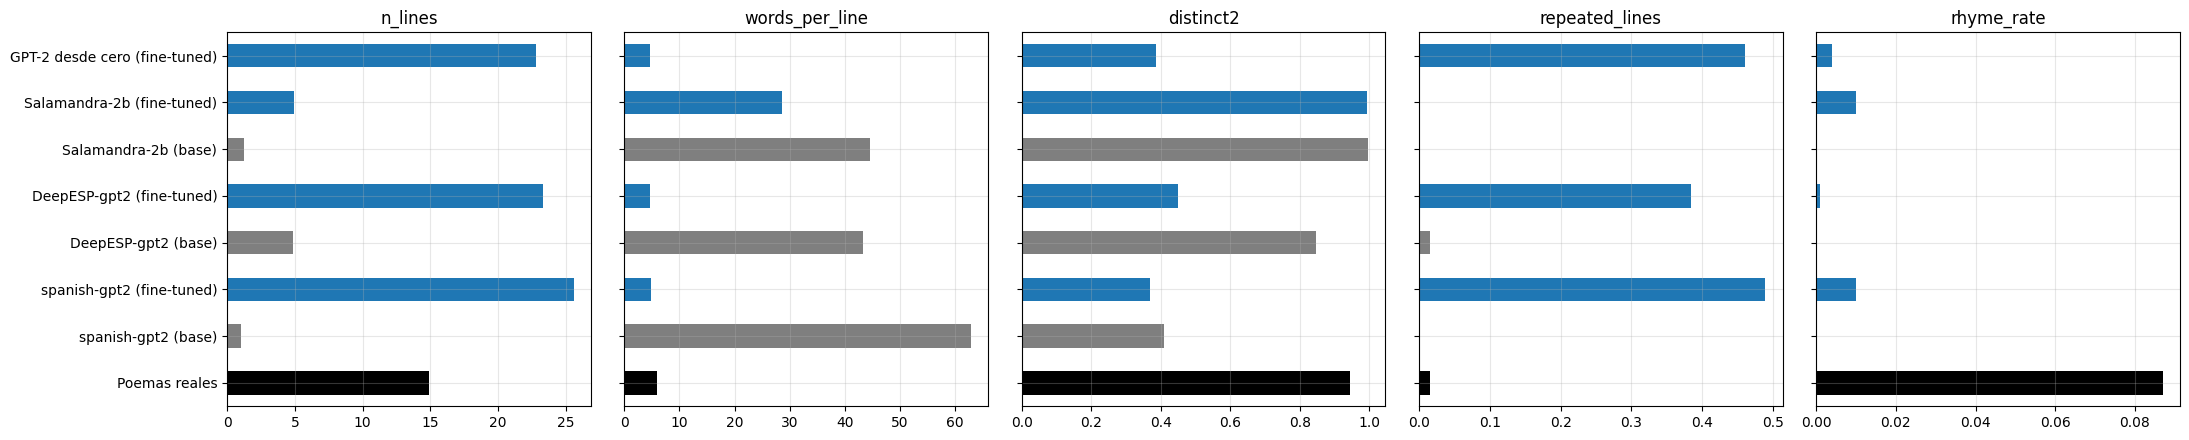

In [ ]:
style_rows = {"Poemas reales": {**ref_style, "closed": np.nan}}
for n, r in RESULTS.items():
    if "style_before" in r:
        style_rows[f"{n} (base)"] = r["style_before"]
    style_rows[f"{n} (fine-tuned)"] = r["style_after"]
cols = ["n_lines", "words_per_line", "distinct2", "repeated_lines", "rhyme_rate", "closed"]
style_df = pd.DataFrame(style_rows).T[cols].round(3)
display(style_df)

colors = ["black" if "reales" in i else ("tab:gray" if "(base)" in i else "tab:blue") for i in style_df.index]
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=True)
for ax, m in zip(axes, cols[:5]):
    style_df[m].plot.barh(ax=ax, color=colors, title=m)
plt.tight_layout()
plt.show()

### 8.4 Decodificación: exploración vs. explotación
La forma de elegir el siguiente token cambia el resultado. Con los modelos ya entrenados comparamos: **greedy** (siempre el token más probable), **muestreo** con temperatura y top-p, **muestreo con penalización de repetición** y **muestreo caliente** (temperatura alta). Un `distinct2` bajo o `repeated_lines` alto delatan bucles de repetición.

In [ ]:
rows = []
for n, r in RESULTS.items():
    for k, v in r["decoding"].items():
        rows.append({"modelo": n, "decodificación": k, **{m: v[m] for m in ["distinct2", "repeated_lines", "words_per_line", "rhyme_rate"]}})
dec_df = pd.DataFrame(rows)
for m in ["distinct2", "repeated_lines"]:
    print(f"\n{m}")
    display(dec_df.pivot(index="decodificación", columns="modelo", values=m).round(3))


distinct2


modelo,DeepESP-gpt2,GPT-2 desde cero,Salamandra-2b,spanish-gpt2
decodificación,,,,
greedy,0.104,0.039,0.982,0.068
muestreo + anti-repetición,0.961,0.979,0.991,0.938
"muestreo base (T=0.9, top_p=0.92)",0.450,0.388,0.994,0.369
muestreo caliente (T=1.3),0.928,0.910,0.996,0.966



repeated_lines


modelo,DeepESP-gpt2,GPT-2 desde cero,Salamandra-2b,spanish-gpt2
decodificación,,,,
greedy,0.857,0.920,0.0,0.857
muestreo + anti-repetición,0.000,0.000,0.0,0.000
"muestreo base (T=0.9, top_p=0.92)",0.384,0.460,0.0,0.489
muestreo caliente (T=1.3),0.010,0.011,0.0,0.000


In [ ]:
# Un ejemplo por estrategia para el primer modelo disponible, en este caso se imprime spanish-gpt2
model_name = next(iter(RESULTS))
print(model_name)
for k, txt in RESULTS[model_name]["decoding_samples"].items():
    print("\n" + "-" * 70 + f"\n[{k}]\n{txt[:350]}")

spanish-gpt2

----------------------------------------------------------------------
[muestreo base (T=0.9, top_p=0.92)]
Un mar de amor
En mi playa
Te espera mi sombra,
En el mar
Y yo, mi sombra,
Te espera,
En mi playa,
Te espera mi sombra,
En el mar
Y yo, mi sombra,
Te espera mi sombra,
En el mar
Y yo, mi sombra,
Te espera,
En el mar
Y yo, mi sombra,
Te espera,
En el mar
Y yo, mi sombra,
Te espera,
En el mar
Y yo, mi sombra,
Te espera,
En el mar
Y yo, mi sombra,
Te 

----------------------------------------------------------------------
[greedy]
El mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
es el mar
y el mar
e

----------------------------------------------------------------------
[muestreo + anti-repetic

## 9. Análisis

**¿Cambió el estilo?** Sí. Antes de entrenar, los GPT-2 escribían texto corrido (1 a 5 líneas de 43 a 63 palabras). Después escriben unas 23-25 líneas de ~5 palabras, como un poema real (5,8 palabras por verso). Salamandra cambió menos la forma: pasó de 1,3 líneas de 45 palabras a 4,7 líneas de 28 palabras, o sea, prosa poética. Sin embargo, su base respondía en inglés ("Sure, here's a short paragraph") y ahora escribe en español con tono literario.

**Los GPT-2 repiten versos.** Con el muestreo normal, entre 34% y 46% de sus versos son copias (en los poemas reales, 1,6%) y caen en bucles como "Ni un mar azul." repetido. Salamandra no repite.

**¿Aprendieron a rimar?** No. Los poemas reales tienen 8,7% de rima y todos los modelos quedan cerca de 0% (medida aproximada).

**¿Qué aporta el pre-entrenamiento?** Mucho. El modelo desde cero quedó peor (1,572 bits por carácter contra 1,39-1,41 de los GPT-2 pre-entrenados), aunque vio 3,6 veces más poemas y entrenó 4,6 veces más tiempo. Aprendió la forma (22,8 líneas de 5,1 palabras), pero no el idioma: su texto es pobre y se repite ("El mar." una y otra vez).

**¿Importa qué vio el modelo antes?** Un poco. Antes de entrenar, DeepESP (Wikipedia + libros) predecía mejor los poemas que spanish-gpt2 (1,994 contra 2,461). Después del fine-tuning quedan casi iguales (1,414 contra 1,391). DeepESP sí cierra mejor el poema (55,6% de sus textos terminan solos, contra 5,6%) y repite menos (34% contra 46% de versos repetidos).

**¿Importa el tamaño?** Sí. Salamandra-2B es el que mejor predice poemas (1,225, unos 12% menos que spanish-gpt2) y su texto es coherente y sin bucles. Ya antes de entrenar (1,359) superaba a los GPT-2 ajustados. Costó 28 minutos contra 7, y solo se entrenó el 0,66% de sus parámetros (LoRA). Su punto débil: escribe párrafos más que versos.

**Curvas de entrenamiento.** La pérdida de evaluación casi no baja después de la época 1-2, mientras la de entrenamiento sigue bajando: con 5.000 poemas bastan 2-3 épocas. El modelo desde cero se estanca hacia la época 10.

**Decodificación.** Greedy hace bucles en los GPT-2 (80-90% de versos repetidos). El muestreo con penalización de repetición elimina los bucles (0% repetidos) y da los poemas más legibles. Con temperatura alta (1,3) tampoco hay bucles, pero en el ejemplo visto el texto pierde sentido. En Salamandra la decodificación casi no importa.

## Conclusiones

- El fine-tuning con poemas cambia la forma del texto: los GPT-2 pasan de texto corrido a versos de ~5 palabras, como los poemas reales. Salamandra cambia menos la forma (sigue escribiendo párrafos), pero ahora en español literario.
- Los GPT-2 pequeños repiten versos con el muestreo normal; el muestreo con penalización de repetición lo corrige casi por completo.
- El pre-entrenamiento pesa más que tener más poemas: el modelo desde cero quedó peor (1,572 contra 1,39-1,41 bits por carácter) con 3,6 veces más datos.
- Un modelo más grande (Salamandra-2B con LoRA) es el que mejor predice poemas (1,225) y escribe más coherente, pero cuesta ~4 veces más tiempo y cambia menos el estilo.
- Ningún modelo aprendió a rimar. Las métricas ayudan a comparar, pero hay que leer los textos.
- El modelo solo reproduce los datos con los que se entrena: curar el corpus (idioma, longitud, duplicados) fue parte central del resultado.

#### Limitaciones y trabajo futuro
- Las generaciones se evalúan con solo 6 prompts (3 muestras cada uno) y una sola ejecución por modelo; los números pueden variar con otra semilla.
- La partición es aleatoria por poema: un mismo autor puede aparecer en entrenamiento y evaluación. Una partición por autor mediría mejor la generalización.
- La métrica de rima es aproximada, y la poesía moderna suele ser verso libre.
- Sin barrido de hiperparámetros; LoRA con `r=16` y 2 épocas podría mejorar con más ajuste o más poemas (`N_TRAIN = None`) para acercar su forma a la de un poema.
- Extensión natural: condicionar la generación con un prefijo de control (p. ej. época o autor) para generar en un estilo concreto.